# 데이터셋 EDA
## 데이터 셋 : [Credit Card Fraud Detection(Kaggle)](https://www.kaggle.com/datasets/kaushalnandania/credit-card-fraud-detection)

| 항목 | 내용 |
|------|------|
| 기간 | 2019-01-01 ~ 2020-06-21 |
| 총 거래 수 | 1,296,675건 |
| 컬럼 수 | 23개 (결측치 없음) |
| 사기 비율 | 0.58% (7,506건) |
| 태스크 | Binary Classification — 사기 거래 탐지 |


## 1. 라이브러리 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Seaborn 테마 설정
sns.set_theme(style='whitegrid', palette='muted')

# 한글 폰트 설정(Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

# 한글 폰트 설정(Mac)
# plt.rcParams['font.family'] = 'AppleGothic'
# plt.rcParams['axes.unicode_minus'] = False

# 한글 폰트 설정(Linux)
# plt.rcParams['font.family'] = 'NanumGothic'
# plt.rcParams['axes.unicode_minus'] = False


## 2. 데이터 로드 및 기본 정보

### 변수 설명

#### 거래 정보
| 변수명 | 타입 | 설명 |
|--------|------|------|
| `trans_date_trans_time` | datetime | 거래 발생 일시 |
| `trans_num` | string | 거래 고유 ID (UUID) |
| `unix_time` | int | 거래 시각 Unix 타임스탬프 (`trans_date_trans_time`과 중복) |
| `amt` | float | 거래 금액 (USD) |
| `merchant` | string | 가맹점 이름 |
| `category` | string | 가맹점 업종 카테고리 (14종) |

#### 카드 소지자 정보
| 변수명 | 타입 | 설명 |
|--------|------|------|
| `cc_num` | int | 신용카드 번호 |
| `first` / `last` | string | 카드 소지자 이름 / 성 |
| `gender` | string | 성별 (`F` / `M`) |
| `dob` | date | 생년월일 |
| `job` | string | 직업 (494종) |
| `street` / `city` / `state` / `zip` | string/int | 거주지 주소 |
| `lat` / `long` | float | 카드 소지자 거주지 위도/경도 |
| `city_pop` | int | 거주 도시 인구 수 |

#### 가맹점 위치
| 변수명 | 타입 | 설명 |
|--------|------|------|
| `merch_lat` / `merch_long` | float | 가맹점 위도 / 경도 |

#### 타겟
| 변수명 | 타입 | 설명 |
|--------|------|------|
| `is_fraud` | int | 사기 여부 — `0` 정상, `1` 사기 |

In [2]:
# 데이터 로드
df = pd.read_csv("..\data\cc_fraud_train.csv", index_col=0) # 경로는 각자 환경에 맞게 수정 필요

# 날짜 컬럼 datetime 형식으로 변환
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

# 기본 정보 확인
print(f"Shape : {df.shape}")
print(f"기간  : {df['trans_date_trans_time'].min()} ~ {df['trans_date_trans_time'].max()}")
print(f"결측치: {df.isnull().sum().sum()}개")
df.head()


Shape : (1296675, 22)
기간  : 2019-01-01 00:00:18 ~ 2020-06-21 12:13:37
결측치: 0개


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
# 데이터 타입 확인
df.dtypes.to_frame('dtype')

,dtype
trans_date_trans_time,datetime64[us]
cc_num,int64
merchant,str
category,str
amt,float64
first,str
last,str
gender,str
street,str
city,str


In [4]:
# 데이터 요약 통계
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
trans_date_trans_time,1296675,NaN,NaN,NaN,2019-10-03 12:47:28.070213,2019-01-01 00:00:18,2019-06-03 19:12:22.500000,2019-10-03 07:35:47,2020-01-28 15:02:55.500000,2020-06-21 12:13:37,NaN
cc_num,1296675.0,NaN,NaN,NaN,417192042079726656.0,60416207185.0,180042946491150.0,3521417320836166.0,4642255475285942.0,4992346398065154048.0,1308806447000240384.0
merchant,1296675,693,fraud_Kilback LLC,4403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1296675,14,gas_transport,131659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amt,1296675.0,NaN,NaN,NaN,70.351035,1.0,9.65,47.52,83.14,28948.9,160.316039
first,1296675,352,Christopher,26669,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,1296675,481,Smith,28794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1296675,2,F,709863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street,1296675,983,864 Reynolds Plains,3123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1296675,894,Birmingham,5617,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. 탐색적 데이터 분석 (EDA)

원본 변수들을 기준으로 클래스 불균형, 금액·카테고리·시간·고객 특성·거리·상관관계·가맹점 위험도를 순서대로 살펴봅니다.

### 3-1. 클래스 불균형 (`is_fraud`)

사기 거래 비중이 얼마나 되는지 확인합니다. 극심한 불균형은 모델 선택과 평가지표 결정에 직접 영향을 줍니다.

In [5]:
counts = df['is_fraud'].value_counts()
print(counts)
print(counts / len(df) * 100)


is_fraud
0    1289169
1       7506
Name: count, dtype: int64
is_fraud
0    99.421135
1     0.578865
Name: count, dtype: float64


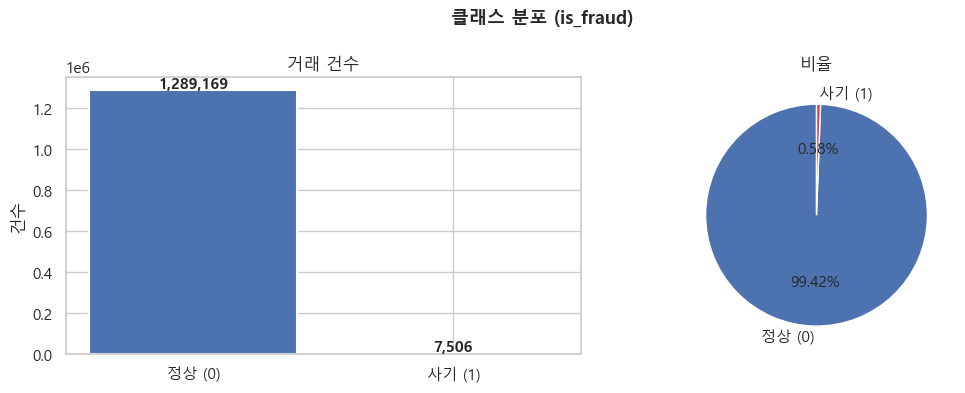

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("클래스 분포 (is_fraud)", fontsize=13, fontweight='bold')

labels = ['정상 (0)', '사기 (1)']
colors = ['#4C72B0', '#DD4444']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title("거래 건수")
axes[0].set_ylabel("건수")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 8000, f"{v:,}", ha='center', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.2f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title("비율")

plt.tight_layout()
plt.show()
# 💡 사기 비율 0.58% → 극심한 클래스 불균형


### 3-2. 거래 금액 (`amt`) 분포

금액 분포가 정상·사기 간에 어떻게 다른지 로그 스케일 히스토그램과 박스플롯으로 비교합니다.

In [7]:
df.groupby('is_fraud')['amt'].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,67.67,154.01,1.00,9.61,47.28,82.54,28948.90
1,7506.0,531.32,390.56,1.06,245.66,396.50,900.88,1376.04


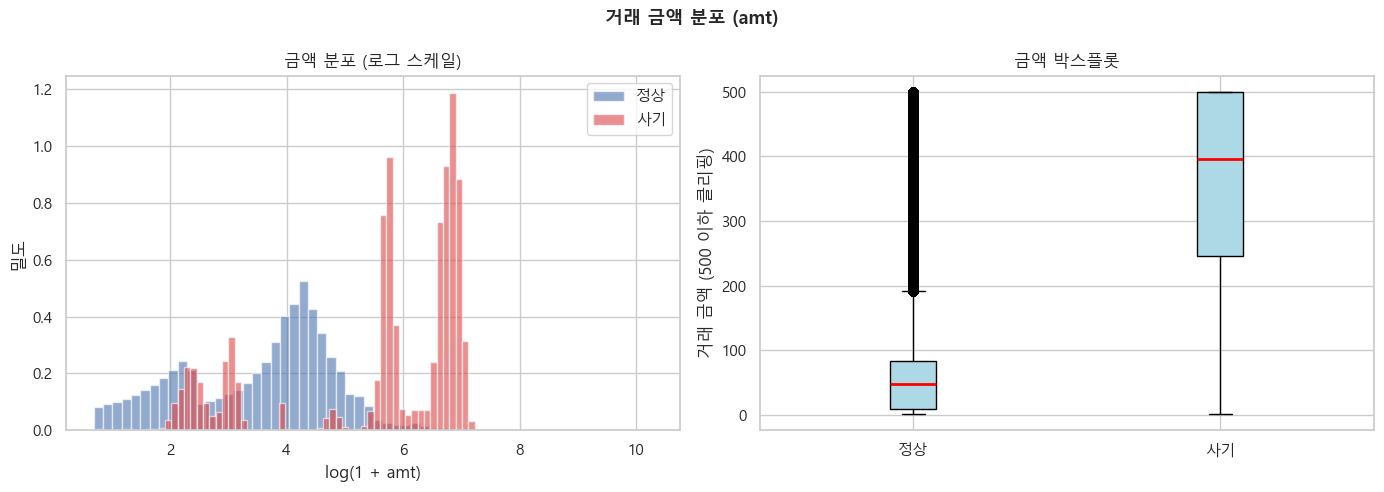

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("거래 금액 분포 (amt)", fontsize=13, fontweight='bold')

for fraud, color, label in [(0, '#4C72B0', '정상'), (1, '#DD4444', '사기')]:
    axes[0].hist(np.log1p(df[df.is_fraud==fraud]['amt']),
                 bins=60, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel("log(1 + amt)")
axes[0].set_ylabel("밀도")
axes[0].set_title("금액 분포 (로그 스케일)")
axes[0].legend()

# 이상치 영향 줄이기 위해 500 이하로 클리핑
axes[1].boxplot(
    [df[df.is_fraud==0]['amt'].clip(upper=500),
     df[df.is_fraud==1]['amt'].clip(upper=500)],
    labels=['정상', '사기'], patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_ylabel("거래 금액 (500 이하 클리핑)")
axes[1].set_title("금액 박스플롯")

plt.tight_layout()
plt.show()
# 💡 사기 거래 평균 금액($527)이 정상($68)보다 약 8배 높음 → 강력한 피처


### 3-3. 카테고리별 분석

`category` 컬럼에는 14개 업종이 있으며, `_net` 접미사는 온라인 거래를 의미합니다.

거래량이 많은 카테고리와 사기율이 높은 카테고리가 반드시 일치하지는 않으므로 두 지표를 나란히 비교합니다.

In [9]:
cat_stats = (df.groupby('category')
               .agg(total=('is_fraud','count'), fraud=('is_fraud','sum'))
               .assign(fraud_rate=lambda x: x['fraud']/x['total']*100)
               .sort_values('fraud_rate', ascending=False))
cat_stats


,total,fraud,fraud_rate
category,,,
shopping_net,97543,1713,1.756149
misc_net,63287,915,1.445795
grocery_pos,123638,1743,1.409761
shopping_pos,116672,843,0.722538
gas_transport,131659,618,0.469394
misc_pos,79655,250,0.313853
grocery_net,45452,134,0.294817
travel,40507,116,0.286370
entertainment,94014,233,0.247835


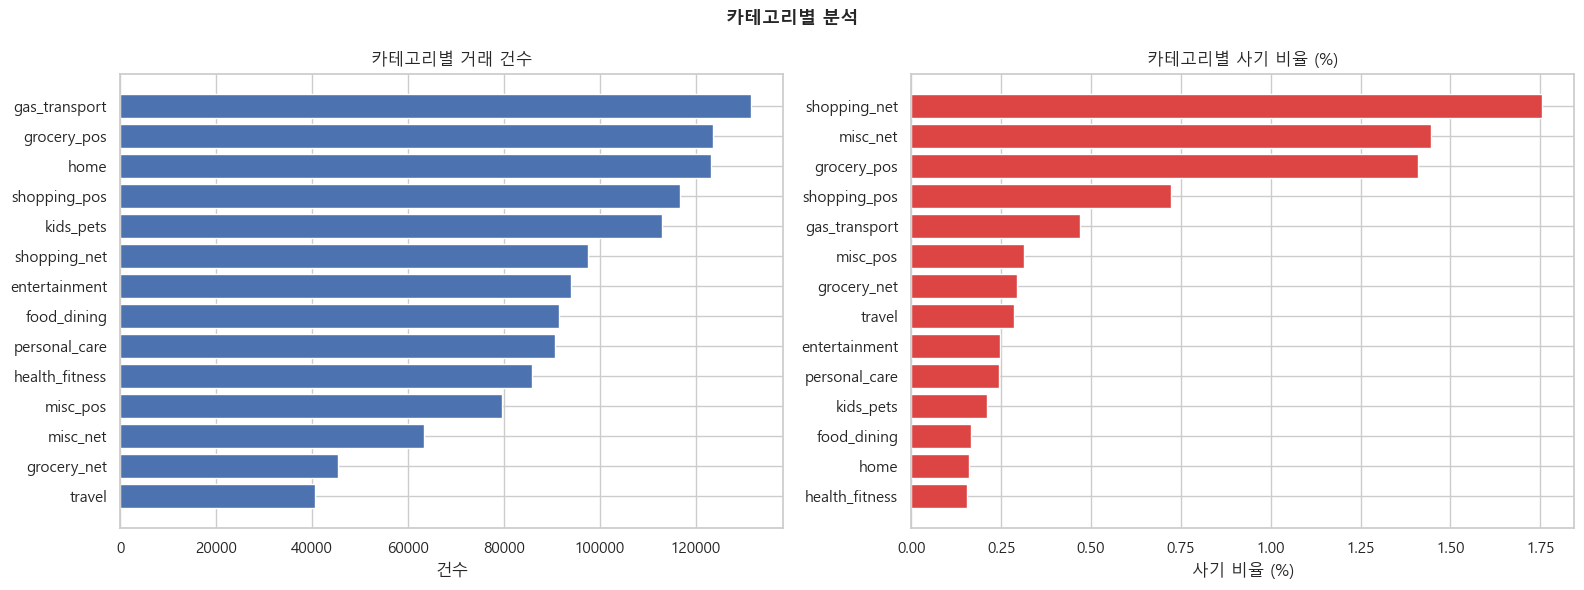

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("카테고리별 분석", fontsize=13, fontweight='bold')

cat_counts = df['category'].value_counts()
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color='#4C72B0')
axes[0].set_title("카테고리별 거래 건수")
axes[0].set_xlabel("건수")

axes[1].barh(cat_stats.index[::-1], cat_stats['fraud_rate'][::-1], color='#DD4444')
axes[1].set_title("카테고리별 사기 비율 (%)")
axes[1].set_xlabel("사기 비율 (%)")

plt.tight_layout()
plt.show()
# 💡 _net(온라인) 카테고리 사기율이 _pos(오프라인)보다 전반적으로 높음


### 3-4. 공통 기본 파생 변수

시간, 나이, 거리처럼 이후 분석과 개인 패턴 변수 생성에 공통으로 쓰이는 기본 파생 변수를 먼저 계산합니다.
| 파생 변수 | 생성 방법 | 의미 |
|-----------|-----------|------|
| `trans_hour` | 거래 시각 → 시간 | 심야 거래 여부 파악 |
| `trans_day` | 거래 시각 → 요일 | 0=월 ~ 6=일 |
| `trans_month` | 거래 시각 → 월 | 계절성 파악 |
| `age` | 거래연도 - 생년 | 카드 소지자 나이 |
| `distance_km` | Haversine(소지자 좌표, 가맹점 좌표) | 물리적 거리 |

In [11]:
# 거래 시간에서 시간/요일/월 추출
df['trans_hour']  = df['trans_date_trans_time'].dt.hour
df['trans_day']   = df['trans_date_trans_time'].dt.dayofweek # 0=월요일, 6=일요일 기준
df['trans_month'] = df['trans_date_trans_time'].dt.month

# 생년월일로 나이 계산
df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year  # 생일 미경과 시 1살 많게 계산될 수 있음 (EDA 수준에서 허용)

# 카드 소지자 거주지 ~ 가맹점 간 직선 거리 계산 (Haversine 공식, 단위: km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # 지구 반경
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi    = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# 기본 파생변수 생성
df['distance_km'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_day,trans_month,age,distance_km
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,1,1,31,78.597568
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,1,1,41,30.212176
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,1,1,57,108.206083
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,1,1,52,95.673231
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,1,1,33,77.556744


### 3-5. 시간 패턴 분석

시간대(0~23시)·요일·월 기준으로 사기 비율과 거래량을 함께 확인합니다.

- `trans_hour` : 0~23시
- `trans_day` : 0=월요일 ~ 6=일요일
- `trans_month` : 1~12월

> 💡 심야(0~4시) 사기 비율이 낮 시간대 대비 현저히 높습니다.

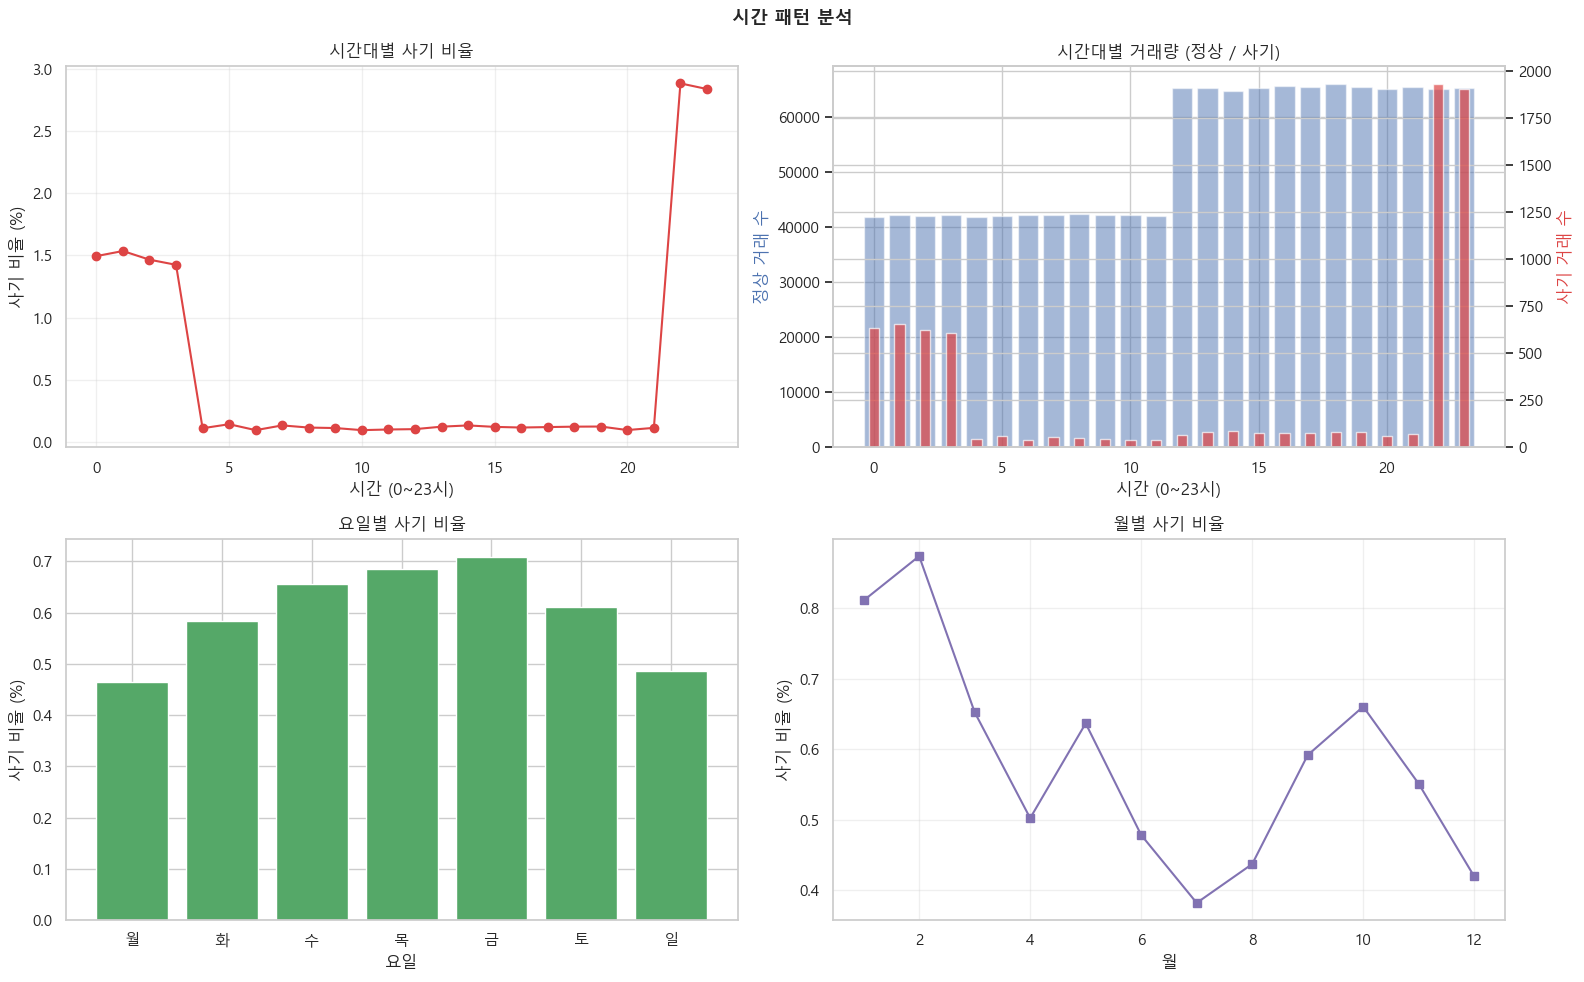

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("시간 패턴 분석", fontsize=13, fontweight='bold')

# 시간대(0~23시)별 사기 비율
hour_stats = df.groupby('trans_hour')['is_fraud'].mean() * 100
axes[0,0].plot(hour_stats.index, hour_stats.values, marker='o', color='#DD4444')
axes[0,0].set_title("시간대별 사기 비율")
axes[0,0].set_xlabel("시간 (0~23시)")
axes[0,0].set_ylabel("사기 비율 (%)")
axes[0,0].grid(True, alpha=0.3)

# 정상/사기 거래량을 좌우 y축으로 분리해서 표시
normal_hour = df[df.is_fraud==0].groupby('trans_hour').size()
fraud_hour  = df[df.is_fraud==1].groupby('trans_hour').size()
ax_r = axes[0,1].twinx()
axes[0,1].bar(normal_hour.index, normal_hour.values, alpha=0.5, color='#4C72B0', label='정상')
ax_r.bar(fraud_hour.index, fraud_hour.values, alpha=0.7, color='#DD4444', width=0.4, label='사기')
axes[0,1].set_title("시간대별 거래량 (정상 / 사기)")
axes[0,1].set_xlabel("시간 (0~23시)")
axes[0,1].set_ylabel("정상 거래 수", color='#4C72B0')
ax_r.set_ylabel("사기 거래 수", color='#DD4444')

# 요일별 사기 비율 (0=월요일)
day_names  = ['월','화','수','목','금','토','일']
day_stats  = df.groupby('trans_day')['is_fraud'].mean() * 100
axes[1,0].bar(day_names, day_stats.values, color='#55A868')
axes[1,0].set_title("요일별 사기 비율")
axes[1,0].set_xlabel("요일")
axes[1,0].set_ylabel("사기 비율 (%)")

# 월별 사기 비율
month_stats = df.groupby('trans_month')['is_fraud'].mean() * 100
axes[1,1].plot(month_stats.index, month_stats.values, marker='s', color='#8172B2')
axes[1,1].set_title("월별 사기 비율")
axes[1,1].set_xlabel("월")
axes[1,1].set_ylabel("사기 비율 (%)")
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 💡 심야(0~4시) 사기 비율이 낮 시간대 대비 현저히 높음
# 💡 금요일과 토요일 사기 비율이 평일보다 높음
# 💡 12월 사기 비율이 다른 달보다 높음

### 3-6. 고객 특성 분석 (나이, 성별)

연령대와 성별에 따른 사기율 차이를 확인합니다. 나이는 6개 구간(`~25`, `26-35`, `36-45`, `46-55`, `56-65`, `65+`)으로 나눠 분포를 비교합니다.

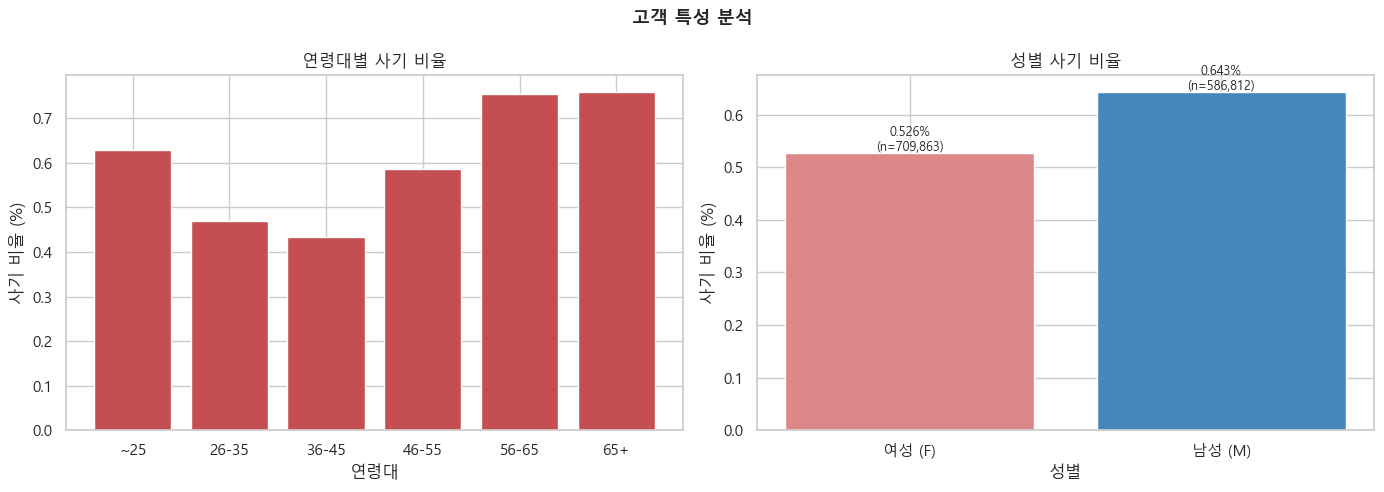

In [13]:
# 나이를 6개 구간으로 나눔
df['age_group'] = pd.cut(df['age'],
    bins=[0,25,35,45,55,65,100],
    labels=['~25','26-35','36-45','46-55','56-65','65+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("고객 특성 분석", fontsize=13, fontweight='bold')

# 연령대별 사기 비율
age_fraud = df.groupby('age_group', observed=True)['is_fraud'].mean() * 100
axes[0].bar(age_fraud.index.astype(str), age_fraud.values, color='#C44E52')
axes[0].set_title("연령대별 사기 비율")
axes[0].set_xlabel("연령대")
axes[0].set_ylabel("사기 비율 (%)")

# 성별 사기 비율 (막대 위에 수치 표기)
gender_fraud = df.groupby('gender')['is_fraud'].agg(['mean','count'])
gender_fraud['mean'] *= 100
axes[1].bar(['여성 (F)','남성 (M)'], gender_fraud['mean'].values, color=['#DD8888','#4488BB'])
axes[1].set_title("성별 사기 비율")
axes[1].set_xlabel("성별")
axes[1].set_ylabel("사기 비율 (%)")
for i, (v, n) in enumerate(zip(gender_fraud['mean'].values, gender_fraud['count'].values)):
    axes[1].text(i, v+0.005, f"{v:.3f}%\n(n={n:,})", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 💡 26-35세 연령대 사기 비율이 가장 높음 (0.75%) → 이 연령층 타겟 마케팅 또는 보안 강화 필요
# 💡 남성 사기 비율(0.60%)이 여성(0.56%)보다 약간 높으나, 차이가 매우 미미해 통계적으로 유의미하지 않을 수 있음
#    → 성별 단독 피처보다는 다른 변수와의 교호작용 관점에서 활용 권장

### 3-7. 소지자 ~ 가맹점 거리 분석

`distance_km` : Haversine 공식으로 카드 소지자 거주지와 가맹점 간의 직선 거리(km)를 계산합니다.

정상·사기 간 거리 분포 차이가 크지 않다면 절대 거리 대신 **개인 기준 이탈 지표(z-score)** 로 변환하는 것이 더 효과적입니다.

> 💡 정상(평균 76.1km)과 사기(76.3km) 거리 분포가 거의 동일 → 단순 거리는 유효한 피처가 아님
> ℹ️ 개인 편차 기반 `dist_zscore` 변수는 섹션 4에서 생성합니다.


In [14]:
df.groupby('is_fraud')['distance_km'].describe().round(2)


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,76.11,29.12,0.02,55.33,78.23,98.50,152.12
1,7506.0,76.27,28.75,0.74,55.63,77.93,98.39,144.52


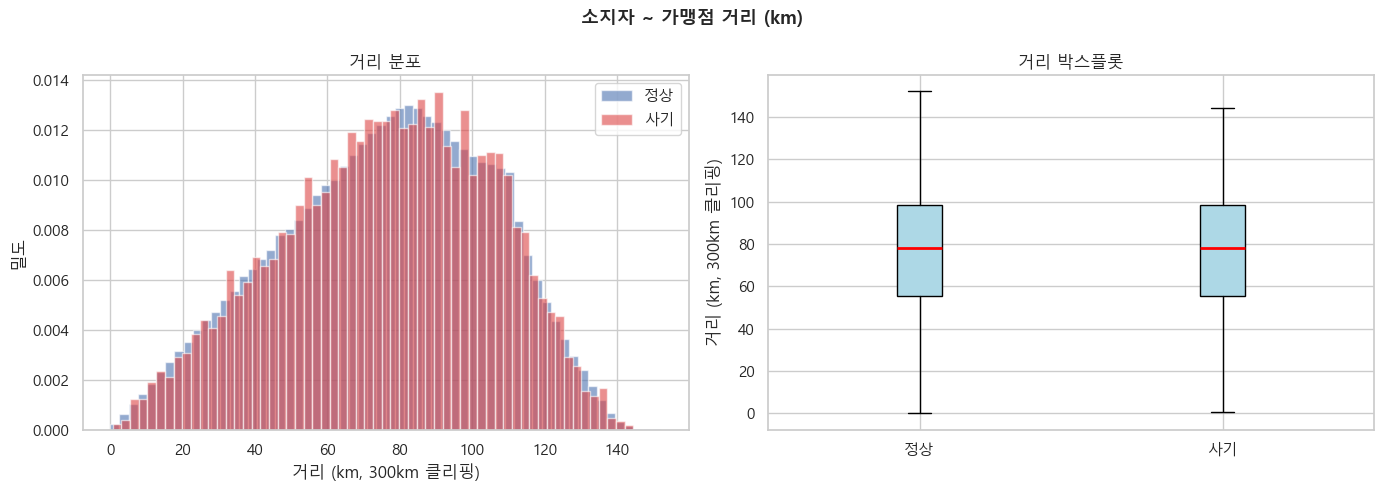

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("소지자 ~ 가맹점 거리 (km)", fontsize=13, fontweight='bold')

# 이상치 영향 줄이기 위해 300km 이하로 클리핑
for fraud, color, label in [(0,'#4C72B0','정상'), (1,'#DD4444','사기')]:
    axes[0].hist(df[df.is_fraud==fraud]['distance_km'].clip(upper=300),
                 bins=60, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel("거리 (km, 300km 클리핑)")
axes[0].set_ylabel("밀도")
axes[0].set_title("거리 분포")
axes[0].legend()

axes[1].boxplot(
    [df[df.is_fraud==0]['distance_km'].clip(upper=300),
     df[df.is_fraud==1]['distance_km'].clip(upper=300)],
    labels=['정상','사기'], patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', linewidth=2)
)
axes[1].set_ylabel("거리 (km, 300km 클리핑)")
axes[1].set_title("거리 박스플롯")

plt.tight_layout()
plt.show()

# 💡 정상(평균 76.1km)과 사기(76.3km) 거리 분포가 거의 동일 → 단순 거리는 유효한 피처가 아님


### 3-8. 수치형 변수 상관관계

주요 수치형 변수와 `is_fraud` 간의 선형 상관계수를 히트맵으로 시각화합니다.

분석 대상 변수: `amt`, `city_pop`, `age`, `distance_km`, `lat`, `long`

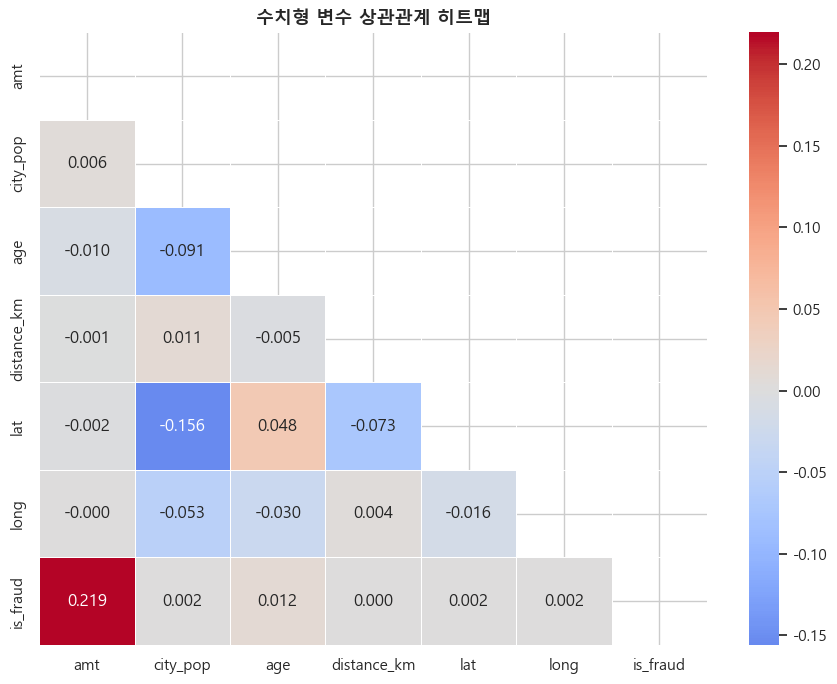

is_fraud       1.000000
amt            0.219404
age            0.012453
city_pop       0.002136
lat            0.001894
long           0.001721
distance_km    0.000403
Name: is_fraud, dtype: float64

In [16]:
num_cols = ['amt','city_pop','age','distance_km','lat','long','is_fraud']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

# 상삼각 마스킹으로 중복 제거
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title("수치형 변수 상관관계 히트맵", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

corr['is_fraud'].sort_values(ascending=False)


### 3-9. 가맹점 위험도 요약

거래량이 너무 작은 가맹점을 제외한 뒤 사기율을 함께 확인합니다.

- **고정 기준** : `min_txn_fixed = 1000`
- **자동 기준** : 거래건수 30% 분위수(`min_txn_auto`)
- **최종 기준** : `max(min_txn_fixed, min_txn_auto)`

전체 가맹점 수: 693
자동 기준(30% 분위수): 1,692건
고정 기준: 1,000건
최종 적용 기준: 1,692건
최종 기준 적용 후 가맹점 수: 485


,threshold,n_merchants
0,100,693
1,500,693
2,1000,594
3,1692,485


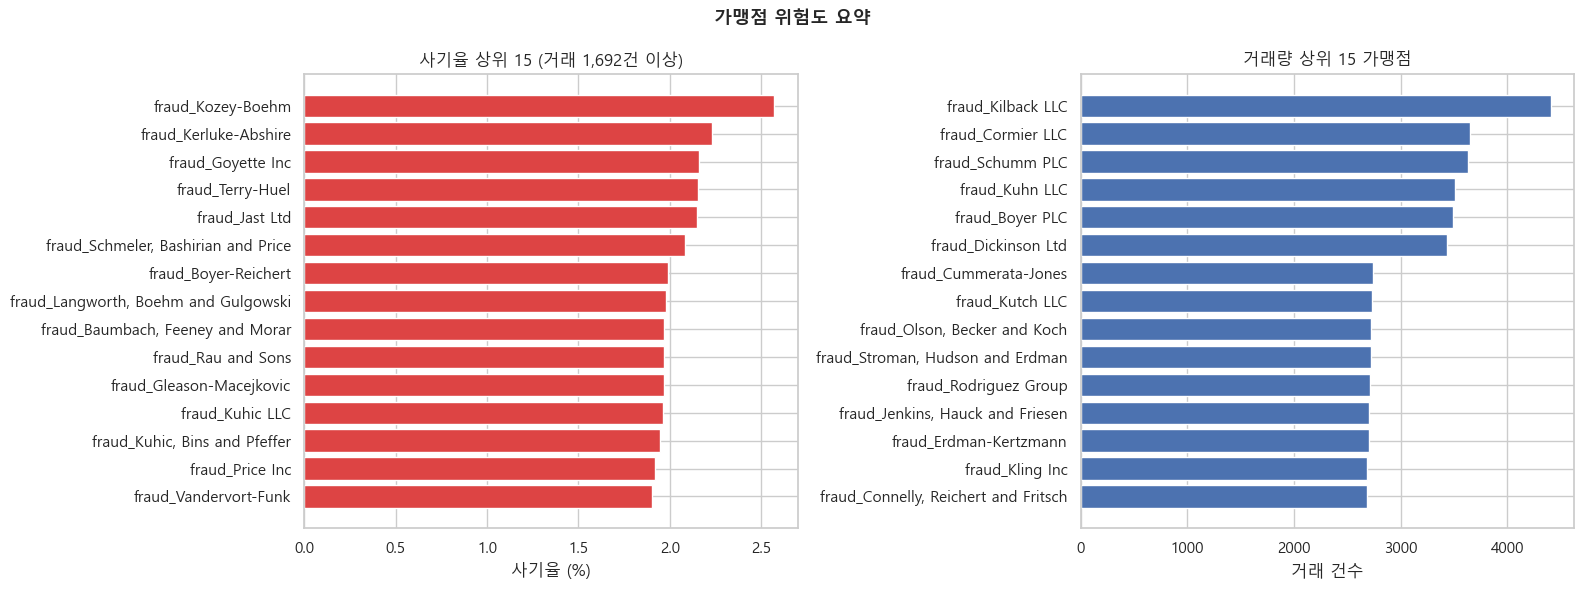

,total_txn,fraud_txn,fraud_rate
merchant,,,
fraud_Kozey-Boehm,1866,48,2.572347
fraud_Kerluke-Abshire,1838,41,2.230686
fraud_Goyette Inc,1943,42,2.161606
fraud_Terry-Huel,1996,43,2.154309
fraud_Jast Ltd,1953,42,2.150538
"fraud_Schmeler, Bashirian and Price",1968,41,2.083333
fraud_Boyer-Reichert,1908,38,1.991614
"fraud_Langworth, Boehm and Gulgowski",1969,39,1.980701
"fraud_Baumbach, Feeney and Morar",1929,38,1.969933


In [17]:
# 가맹점별 거래수/사기수/사기율 집계
merchant_risk = (
    df.groupby('merchant')
      .agg(total_txn=('is_fraud', 'size'), fraud_txn=('is_fraud', 'sum'))
      .assign(fraud_rate=lambda x: x['fraud_txn'] / x['total_txn'] * 100)
      .sort_values(['fraud_rate', 'fraud_txn'], ascending=[False, False])
)

# 거래건수 필터 기준: 고정값 + 자동 분위수 비교
min_txn_fixed = 1000
min_txn_auto = int(merchant_risk['total_txn'].quantile(0.30))
min_txn = max(min_txn_fixed, min_txn_auto)

# 후보 기준별로 몇 개 가맹점이 남는지 확인
candidate_thresholds = sorted(set([100, 500, min_txn_auto, min_txn_fixed, min_txn]))
threshold_summary = []
for th in candidate_thresholds:
    n_merchants = (merchant_risk['total_txn'] >= th).sum()
    threshold_summary.append({'threshold': th, 'n_merchants': int(n_merchants)})
threshold_summary_df = pd.DataFrame(threshold_summary)

merchant_risk_filtered = merchant_risk[merchant_risk['total_txn'] >= min_txn].copy()
if merchant_risk_filtered.empty:
    # 예외적으로 고정 기준이 너무 높을 경우 자동 기준으로 완화
    min_txn = min_txn_auto
    merchant_risk_filtered = merchant_risk[merchant_risk['total_txn'] >= min_txn].copy()

top_rate = merchant_risk_filtered.head(15)
top_volume = merchant_risk.sort_values('total_txn', ascending=False).head(15)

print(f"전체 가맹점 수: {merchant_risk.shape[0]:,}")
print(f"자동 기준(30% 분위수): {min_txn_auto:,}건")
print(f"고정 기준: {min_txn_fixed:,}건")
print(f"최종 적용 기준: {min_txn:,}건")
print(f"최종 기준 적용 후 가맹점 수: {merchant_risk_filtered.shape[0]:,}")
display(threshold_summary_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("가맹점 위험도 요약", fontsize=13, fontweight='bold')

axes[0].barh(top_rate.index[::-1], top_rate['fraud_rate'][::-1], color='#DD4444')
axes[0].set_title(f"사기율 상위 15 (거래 {min_txn:,}건 이상)")
axes[0].set_xlabel('사기율 (%)')

axes[1].barh(top_volume.index[::-1], top_volume['total_txn'][::-1], color='#4C72B0')
axes[1].set_title('거래량 상위 15 가맹점')
axes[1].set_xlabel('거래 건수')

plt.tight_layout()
plt.show()

display(top_rate[['total_txn', 'fraud_txn', 'fraud_rate']].head(10))

## 4. 개인 패턴 기반 파생 변수

EDA에서 확인한 인사이트를 바탕으로 카드별 행동 편차를 포착하는 개인 패턴 변수를 생성합니다.

카드별 평균 행동 대비 이탈을 포착하는 변수들입니다.

**유지할 변수** — 사기 탐지 모델의 주요 피처로 사용

| 파생 변수 | 생성 방법 | 의미 |
|-----------|-----------|------|
| `amt_zscore` | 카드별 평균 대비 금액 이탈 | 개인 소비 패턴 대비 이상 금액 |
| `hour_dev` | 카드별 평균 거래 시간과의 차이 | 평소 거래 시간대에서 벗어난 정도 |
| `high_amt_far` | 고액 + 원거리 동시 발생 | 복합 이상 패턴 |

**보류할 변수** — 분석은 해두되, 단독 기여가 낮아 보조 피처로만 활용

| 파생 변수 | 생성 방법 | 의미 |
|-----------|-----------|------|
| `dist_zscore` | 카드별 평균 대비 거리 이탈 | 개인 이동 반경 대비 이상 거리 |
| `is_night` | 거래 시각이 0~4시인지 여부 | 심야 거래 여부 |
| `time_since_last_min` | 직전 거래로부터 경과 시간(분) | 짧은 간격의 연속 거래 탐지 |
| `tx_count_1h` | 1시간 내 거래 여부 | 짧은 시간 내 반복 거래 탐지 |
| `dist_outlier` | 거리 z-score의 2σ 초과 여부 | 평소 이동 범위에서 벗어난 거래 |
| `night_and_far` | 심야 + 원거리 동시 발생 | 복합 이상 패턴 |

In [18]:
# 카드별 개인 패턴 통계 생성
card_stats = df.groupby('cc_num').agg(
    card_avg_amt  = ('amt',         'mean'),
    card_std_amt  = ('amt',         'std'),
    card_avg_dist = ('distance_km', 'mean'),
    card_std_dist = ('distance_km', 'std'),
    card_avg_hour = ('trans_hour',  'mean'),
    card_tx_count = ('amt',         'count'),
).reset_index()

# 표준편차 0이면 z-score 계산 시 0 나눗셈 발생 → 1로 대체
card_stats['card_std_amt']  = card_stats['card_std_amt'].fillna(1).replace(0, 1)
card_stats['card_std_dist'] = card_stats['card_std_dist'].fillna(1).replace(0, 1)

df = df.merge(card_stats, on='cc_num', how='left')

# 카드별 평균에서 얼마나 벗어났는지 계산
df['amt_zscore'] = (df['amt'] - df['card_avg_amt']) / df['card_std_amt']
df['hour_dev'] = (df['trans_hour'] - df['card_avg_hour']).abs()

# 보류 피처도 같이 계산은 해두되, 최종 분석에서는 보조적으로만 본다.
df['dist_zscore'] = (df['distance_km'] - df['card_avg_dist']) / df['card_std_dist']
df['is_night'] = df['trans_hour'].between(0, 4).astype(int)

# 직전 거래로부터 경과 시간 (카드별 정렬 후 shift)
df = df.sort_values(['cc_num', 'trans_date_trans_time']).copy()
df['prev_trans_time'] = df.groupby('cc_num')['trans_date_trans_time'].shift(1)
df['time_since_last_min'] = (
    (df['trans_date_trans_time'] - df['prev_trans_time']).dt.total_seconds() / 60
).fillna(1440)

# 1시간 내 동일 카드 연속 거래 횟수
df['tx_count_1h'] = (df['time_since_last_min'] < 60).astype(int)

# 복합 변수
df['dist_outlier'] = (df['dist_zscore'].abs() > 2).astype(int)
df['night_and_far'] = ((df['is_night'] == 1) & (df['dist_zscore'] > 1)).astype(int)
df['high_amt_far'] = ((df['amt_zscore'] > 2) & (df['dist_zscore'] > 1)).astype(int)

# 확인용 변수 목록
keep_features = ['amt_zscore', 'hour_dev', 'high_amt_far']
hold_features = ['dist_zscore', 'is_night', 'time_since_last_min', 'tx_count_1h', 'dist_outlier', 'night_and_far']

# 중간 계산용 컬럼 정리 (분석에 불필요)
df.drop(columns=['prev_trans_time'], inplace=True)

print('개인 패턴 기반 파생 변수 생성 완료')
display(df[keep_features].describe().round(3))
display(df[hold_features].describe().round(3))

개인 패턴 기반 파생 변수 생성 완료


,amt_zscore,hour_dev,high_amt_far
count,1296675.000,1296675.000,1296675.000
mean,-0.000,5.590,0.004
std,1.000,3.600,0.061
min,-2.825,0.000,0.000
25%,-0.395,2.359,0.000
50%,-0.179,5.298,0.000
75%,0.094,8.310,0.000
max,52.890,20.455,1.000


,dist_zscore,is_night,time_since_last_min,tx_count_1h,dist_outlier,night_and_far
count,1296675.000,1296675.000,1296675.000,1296675.000,1296675.000,1296675.000
mean,-0.000,0.164,542.098,0.164,0.031,0.029
std,1.000,0.370,790.104,0.370,0.174,0.169
min,-2.834,0.000,0.000,0.000,0.000,0.000
25%,-0.713,0.000,100.317,0.000,0.000,0.000
50%,0.075,0.000,276.383,0.000,0.000,0.000
75%,0.767,0.000,671.817,0.000,0.000,0.000
max,2.627,1.000,22357.850,1.000,1.000,1.000


## 5. 개인 패턴 기반 파생 변수 유효성 검증

생성된 파생 변수가 실제로 `is_fraud`와 유의미한 관계를 갖는지 상관계수와 분포 비교로 확인합니다.

In [19]:
# 각 파생변수와 is_fraud 간 상관계수 계산 (절대값 기준 내림차순 정렬)
corr_with_fraud = (df[keep_features + hold_features + ['is_fraud']]
                   .corr()['is_fraud']
                   .drop('is_fraud')
                   .sort_values(key=abs, ascending=False))

corr_df = corr_with_fraud.reset_index()
corr_df.columns = ['변수명', '상관계수']
corr_df['절대값'] = corr_df['상관계수'].abs()
corr_df['평가'] = corr_df['절대값'].apply(
    lambda x: '🔥 강함' if x > 0.1 else ('✅ 유효' if x > 0.05 else '❌ 미미')
)
corr_df

,변수명,상관계수,절대값,평가
0,amt_zscore,0.244585,0.244585,🔥 강함
1,high_amt_far,0.115628,0.115628,🔥 강함
2,hour_dev,0.084238,0.084238,✅ 유효
3,tx_count_1h,0.055908,0.055908,✅ 유효
4,is_night,0.036844,0.036844,❌ 미미
5,time_since_last_min,-0.016984,0.016984,❌ 미미
6,night_and_far,0.013587,0.013587,❌ 미미
7,dist_outlier,-0.001849,0.001849,❌ 미미
8,dist_zscore,0.000405,0.000405,❌ 미미


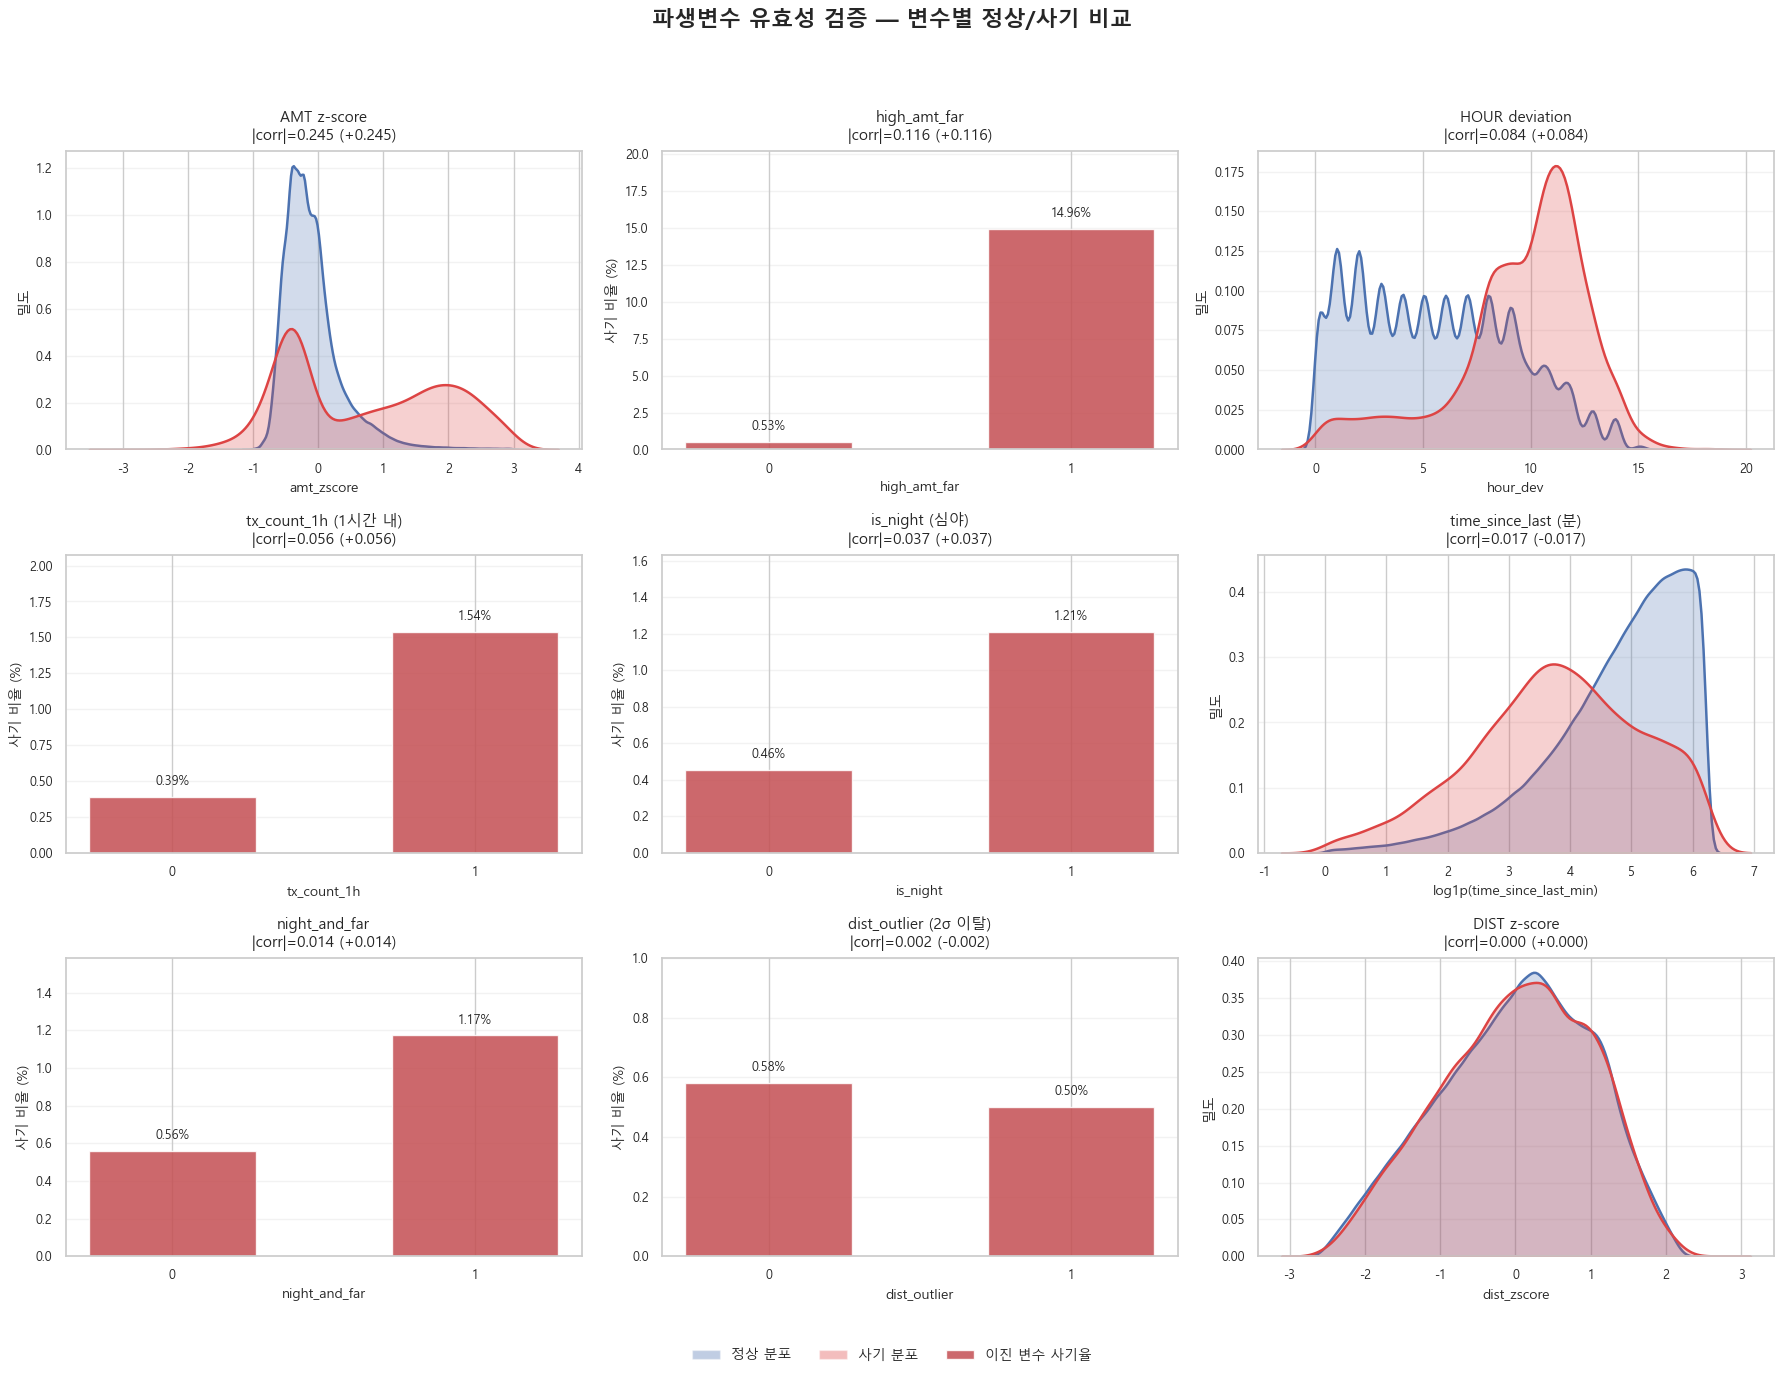

In [20]:
from matplotlib.patches import Patch # 범례용 패치

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("파생변수 유효성 검증 — 변수별 정상/사기 비교", fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten()

plot_configs = [
    ('amt_zscore',          'AMT z-score',            'continuous', -3, 3),
    ('high_amt_far',        'high_amt_far',           'binary',     None, None),
    ('hour_dev',            'HOUR deviation',         'continuous', 0,    20),
    ('is_night',            'is_night (심야)',         'binary',     None, None),
    ('night_and_far',       'night_and_far',          'binary',     None, None),
    ('dist_zscore',         'DIST z-score',           'continuous', -3,   3),
    ('time_since_last_min', 'time_since_last (분)',   'continuous', 0,    500),
    ('tx_count_1h',         'tx_count_1h (1시간 내)', 'binary',     None, None),
    ('dist_outlier',        'dist_outlier (2σ 이탈)', 'binary',     None, None),
]

# 상관 절대값 기준으로 자동 정렬해 중요한 변수부터 먼저 보이게 배치
plot_configs = sorted(plot_configs, key=lambda x: abs(corr_with_fraud[x[0]]), reverse=True)

normal_color = '#4C72B0'
fraud_color = '#DD4444'
binary_color = '#C44E52'

for ax, (col, title, var_type, lower, upper) in zip(axes, plot_configs):
    data = df[[col, 'is_fraud']].dropna().copy()
    corr_val = corr_with_fraud[col]
    abs_corr = abs(corr_val)

    if var_type == 'binary':
        fraud_rate = data.groupby(col)['is_fraud'].mean().reindex([0, 1], fill_value=0) * 100
        bars = ax.bar(['0', '1'], fraud_rate.values, color=binary_color, alpha=0.85, width=0.55)
        y_max = max(1.0, fraud_rate.max() * 1.35)
        ax.set_ylim(0, y_max)
        ax.set_ylabel('사기 비율 (%)', fontsize=10)

        for bar, val in zip(bars, fraud_rate.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + y_max * 0.03,
                f'{val:.2f}%',
                ha='center', va='bottom', fontsize=9
            )
    else:
        # 경계값으로 단순 클리핑하지 않고 범위 밖을 제외해 edge spike를 줄인다.
        if lower is not None:
            data = data[data[col] >= lower]
        if upper is not None:
            data = data[data[col] <= upper]

        # 시간 간격 변수는 로그 스케일로 압축해 분포를 한눈에 보이게 한다.
        plot_col = col
        x_label = col
        if col == 'time_since_last_min':
            data = data.copy()
            data['time_since_last_min_log1p'] = np.log1p(data[col])
            plot_col = 'time_since_last_min_log1p'
            x_label = 'log1p(time_since_last_min)'

        normal_vals = data.loc[data['is_fraud'] == 0, plot_col]
        fraud_vals = data.loc[data['is_fraud'] == 1, plot_col]

        sns.kdeplot(normal_vals, ax=ax, color=normal_color, fill=True, alpha=0.25, linewidth=1.8, label='정상')
        sns.kdeplot(fraud_vals, ax=ax, color=fraud_color, fill=True, alpha=0.25, linewidth=1.8, label='사기')
        ax.set_ylabel('밀도', fontsize=10)
        ax.set_xlabel(x_label, fontsize=10)

    ax.set_title(f"{title}\n|corr|={abs_corr:.3f} ({corr_val:+.3f})", fontsize=11, pad=8)
    if var_type == 'binary':
        ax.set_xlabel(col, fontsize=10)
    ax.grid(axis='y', alpha=0.25)
    ax.tick_params(axis='both', labelsize=9)

legend_handles = [
    Patch(facecolor=normal_color, alpha=0.35, label='정상 분포'),
    Patch(facecolor=fraud_color, alpha=0.35, label='사기 분포'),
    Patch(facecolor=binary_color, alpha=0.85, label='이진 변수 사기율'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.02))

plt.tight_layout(rect=[0, 0.06, 1, 0.965])
plt.show()


## 6. 심화 분석

단일 변수 분석을 넘어 시간 드리프트, 카테고리-시간대 교차, 카드 단위 행태 안정성을 살펴봅니다.

### 6-1. 시간 드리프트 분석

시간이 지나면서 데이터 분포와 사기율이 변하는지 월 단위로 확인합니다.

- 월별 사기율
- 월별 평균 거래금액
- 월별 거래량

> 💡 사기율과 거래량은 월별 변동이 있어, 시간 기반 검증과 주기적 재학습이 필요합니다.

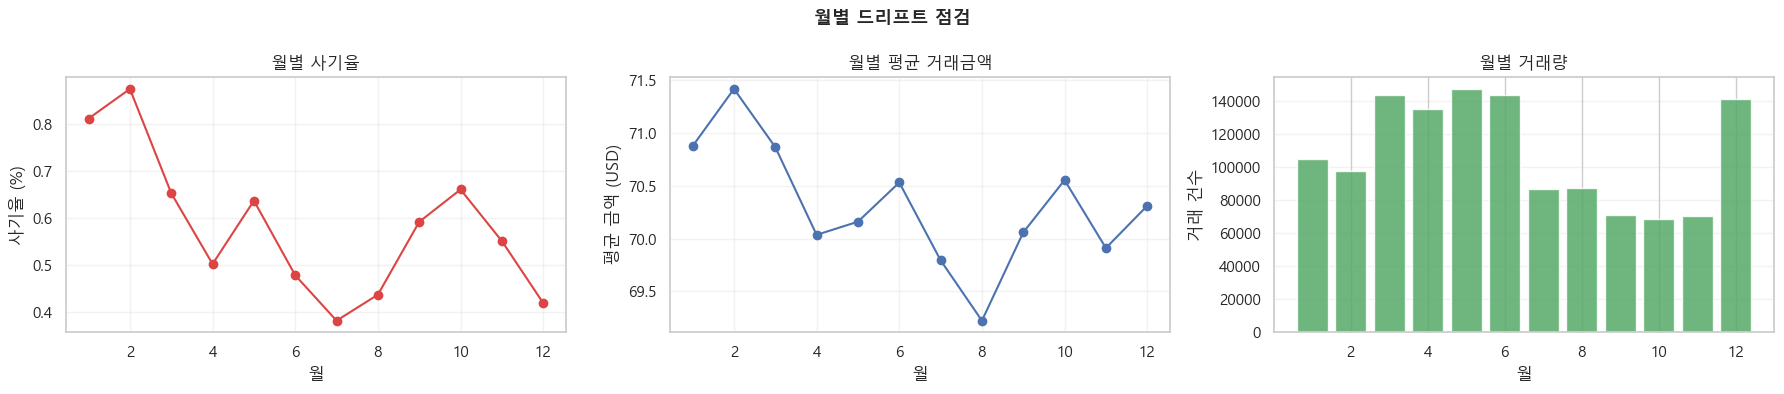

In [21]:
# trans_month는 섹션 3-4에서 이미 생성됨; 셀 실행 순서가 달라질 경우를 대비한 안전 가드
if 'trans_month' not in df.columns:
    df['trans_month'] = df['trans_date_trans_time'].dt.month

# 월별 핵심 지표 집계
monthly_drift = (
    df.groupby('trans_month')
      .agg(
          fraud_rate=('is_fraud', 'mean'),      # 사기 비율
          avg_amt=('amt', 'mean'),               # 평균 거래금액
          tx_count=('is_fraud', 'size')          # 거래량
      )
      .reset_index()
      .sort_values('trans_month')
)
monthly_drift['fraud_rate'] *= 100

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('월별 드리프트 점검', fontsize=13, fontweight='bold')

axes[0].plot(monthly_drift['trans_month'], monthly_drift['fraud_rate'], marker='o', color='#DD4444')
axes[0].set_title('월별 사기율')
axes[0].set_xlabel('월')
axes[0].set_ylabel('사기율 (%)')
axes[0].grid(alpha=0.25)

axes[1].plot(monthly_drift['trans_month'], monthly_drift['avg_amt'], marker='o', color='#4C72B0')
axes[1].set_title('월별 평균 거래금액')
axes[1].set_xlabel('월')
axes[1].set_ylabel('평균 금액 (USD)')
axes[1].grid(alpha=0.25)

axes[2].bar(monthly_drift['trans_month'], monthly_drift['tx_count'], color='#55A868', alpha=0.85)
axes[2].set_title('월별 거래량')
axes[2].set_xlabel('월')
axes[2].set_ylabel('거래 건수')
axes[2].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

### 6-2. 카테고리 × 시간대 교차 분석

카테고리와 시간대가 결합될 때 사기율이 어떻게 달라지는지 히트맵으로 확인합니다.

- 사기율 히트맵 (카테고리 × 시간대)
- 거래량 히트맵 (로그 스케일)

> 💡 특정 카테고리와 특정 시간대가 결합될 때 위험이 집중되므로, 단일 변수보다 교차 피처가 더 효과적입니다.

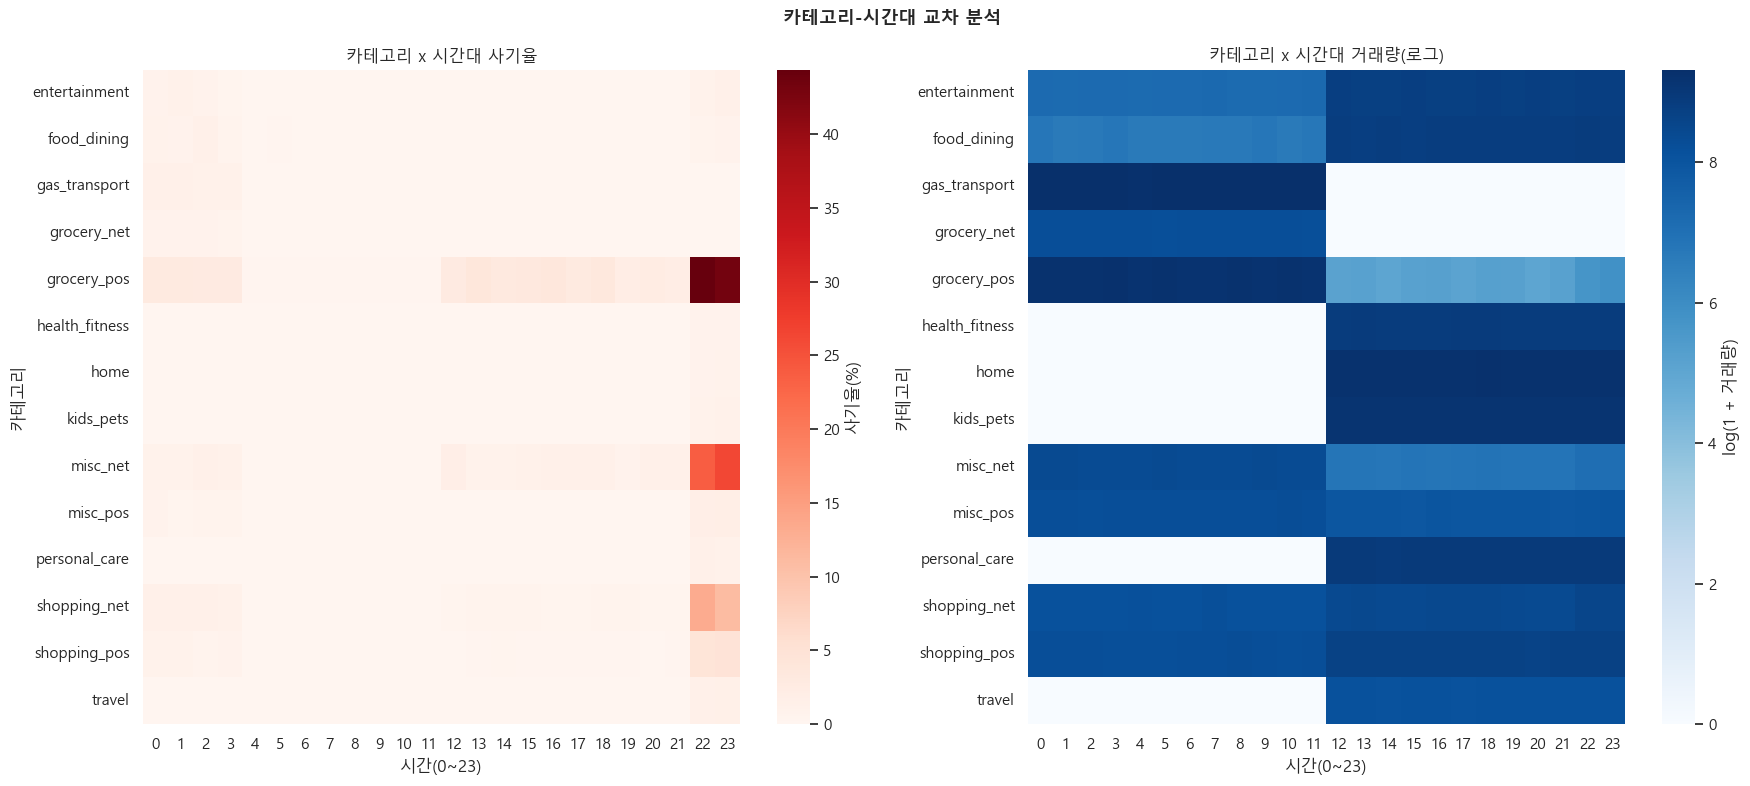

In [22]:
# trans_hour는 섹션 3-4에서 이미 생성됨; 셀 실행 순서가 달라질 경우를 대비한 안전 가드
if 'trans_hour' not in df.columns:
    df['trans_hour'] = df['trans_date_trans_time'].dt.hour

# 카테고리 x 시간대 사기율(%)
cat_hour_fraud = (
    df.pivot_table(index='category', columns='trans_hour', values='is_fraud', aggfunc='mean')
      .fillna(0) * 100
)

# 카테고리 x 시간대 거래량 (로그 변환으로 스케일 압축)
cat_hour_volume = (
    df.pivot_table(index='category', columns='trans_hour', values='is_fraud', aggfunc='size')
      .fillna(0)
)
cat_hour_volume_log = np.log1p(cat_hour_volume)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('카테고리-시간대 교차 분석', fontsize=13, fontweight='bold')

sns.heatmap(cat_hour_fraud, cmap='Reds', ax=axes[0], cbar_kws={'label': '사기율(%)'})
axes[0].set_title('카테고리 x 시간대 사기율')
axes[0].set_xlabel('시간(0~23)')
axes[0].set_ylabel('카테고리')

sns.heatmap(cat_hour_volume_log, cmap='Blues', ax=axes[1], cbar_kws={'label': 'log(1 + 거래량)'})
axes[1].set_title('카테고리 x 시간대 거래량(로그)')
axes[1].set_xlabel('시간(0~23)')
axes[1].set_ylabel('카테고리')

plt.tight_layout()
plt.show()

### 6-3. 카드 단위 행태 안정성 분석

카드별 활동량과 사기율 분포를 함께 보며 개인 패턴 기반 피처의 타당성을 점검합니다.

- 카드별 거래 수 분포
- 카드별 사기율 분포
- 거래 수가 충분한 카드 중 위험 카드 샘플

> 💡 카드별 행동 편차가 뚜렷하므로, 개인 기준 이탈형 피처(`amt_zscore`, `hour_dev`)가 유효합니다.

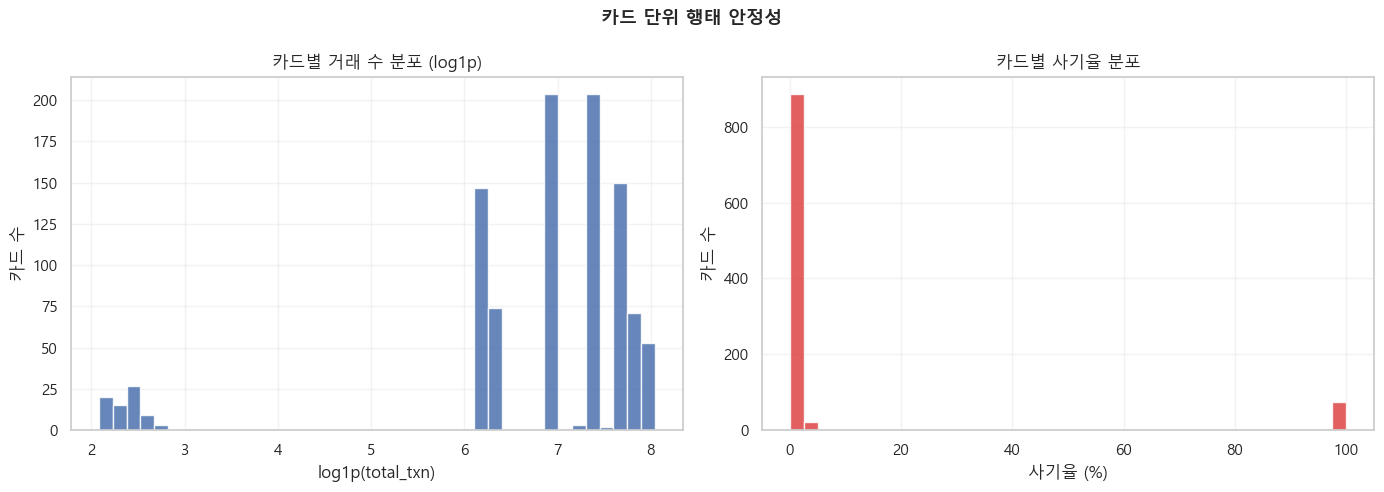

전체 카드 수: 983
거래 200건 이상 카드 수: 908


,total_txn,fraud_txn,fraud_rate,avg_amt,std_amt,unique_category
cc_num,,,,,,
4874006077381178,516,16,3.100775,65.853450,123.778748,14
3534093764340240,493,15,3.042596,72.776673,148.593473,14
342360239917375,504,15,2.976190,70.994048,136.512477,14
676326610042,504,15,2.976190,92.481012,131.435199,14
2227671554547514,545,16,2.935780,92.456018,145.559510,14
5289285402893489,511,15,2.935421,63.201350,136.835319,14
36890292963032,514,15,2.918288,72.870992,143.889095,14
2229824890647120,529,15,2.835539,70.289509,130.935479,14
5154903938030655,529,15,2.835539,95.952250,162.396329,14


In [23]:
# 카드별 집계 지표 생성
card_behavior = (
    df.groupby('cc_num')
      .agg(
          total_txn=('is_fraud', 'size'),
          fraud_txn=('is_fraud', 'sum'),
          avg_amt=('amt', 'mean'),
          std_amt=('amt', 'std'),
          unique_category=('category', 'nunique')
      )
      .assign(
          fraud_rate=lambda x: x['fraud_txn'] / x['total_txn'] * 100,
          std_amt=lambda x: x['std_amt'].fillna(0)
      )
      .sort_values('total_txn', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('카드 단위 행태 안정성', fontsize=13, fontweight='bold')

# 카드별 거래 수는 편차가 크므로 로그 스케일로 분포 확인
axes[0].hist(np.log1p(card_behavior['total_txn']), bins=40, color='#4C72B0', alpha=0.85)
axes[0].set_title('카드별 거래 수 분포 (log1p)')
axes[0].set_xlabel('log1p(total_txn)')
axes[0].set_ylabel('카드 수')
axes[0].grid(alpha=0.25)

axes[1].hist(card_behavior['fraud_rate'], bins=40, color='#DD4444', alpha=0.85)
axes[1].set_title('카드별 사기율 분포')
axes[1].set_xlabel('사기율 (%)')
axes[1].set_ylabel('카드 수')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# 거래 수가 충분한 카드 중 사기율 상위 샘플 확인
min_card_txn = 200
high_risk_cards = (
    card_behavior[card_behavior['total_txn'] >= min_card_txn]
      .sort_values(['fraud_rate', 'fraud_txn'], ascending=[False, False])
      .head(15)
)

print(f"전체 카드 수: {card_behavior.shape[0]:,}")
print(f"거래 {min_card_txn}건 이상 카드 수: {(card_behavior['total_txn'] >= min_card_txn).sum():,}")
display(high_risk_cards[['total_txn', 'fraud_txn', 'fraud_rate', 'avg_amt', 'std_amt', 'unique_category']])

## 7. EDA 종합 요약 및 모델링 방향

### 주요 인사이트

| # | 항목 | 인사이트 |
|---|------|----------|
| 1 | 클래스 불균형 | 사기 비율 0.58% → SMOTE 또는 `class_weight='balanced'` 필수 |
| 2 | 거래 금액 | 사기 평균 $527 vs 정상 $68 — 고액 거래 주의 |
| 3 | 카테고리 | `shopping_net`, `grocery_net` 등 온라인 채널 사기율 높음 |
| 4 | 시간대 | 심야(0~4시) 사기 비율 급등 |
| 5 | 거리 | 절대 거리는 구분력이 낮고, 개인 편차 기반 변수로 변환이 더 유효 |
| 6 | 개인 패턴 변수 | `amt_zscore`, `high_amt_far`, `hour_dev`가 상대적으로 유효 |

### 주요 인사이트 상세 해설

- **클래스 불균형은 모델 성능 착시를 만든다**
  - 전체 데이터에서 사기 비중이 매우 낮아, 단순 정확도(Accuracy)만 보면 성능이 좋아 보일 수 있습니다.
  - 실제 운영 목표는 정상 거래를 최대한 유지하면서 사기를 놓치지 않는 것이므로, `Recall`, `Precision`, `F1`, `PR-AUC` 중심으로 판단해야 합니다.

- **금액은 가장 직관적인 위험 신호다**
  - 사기 거래의 평균 금액이 정상 거래보다 크게 높아, 고액 거래 자체가 강한 경고 신호로 작동합니다.
  - 다만 고객마다 소비 수준이 다르므로 절대 금액만 쓰기보다 카드별 편차를 반영한 `amt_zscore`가 더 안정적입니다.

- **온라인 업종은 공격 표면이 넓다**
  - `_net` 계열 카테고리에서 사기율이 높아 비대면 채널의 취약성이 확인됩니다.
  - 업종 원-핫 인코딩 외에도, 카테고리별 과거 사기율(타깃 누출 방지 방식) 기반 인코딩을 고려할 수 있습니다.

- **시간대 패턴은 룰 기반 탐지와 궁합이 좋다**
  - 심야 시간대는 사용자 행동 분포가 얇아 이상 거래가 상대적으로 두드러집니다.
  - 운영에서는 `is_night` 단독보다 `is_night + 고액`, `is_night + 낯선 카테고리` 같은 복합 규칙이 효과적입니다.

- **거리 절대값보다 개인 기준 이탈이 중요하다**
  - 정상/사기의 평균 거리 차이는 작아 절대 거리 변수 하나로는 분리력이 낮습니다.
  - 사용자별 이동 반경을 기준으로 한 `dist_zscore` 같은 상대 지표가 더 합리적이며, 이번 데이터에서는 거리 계열의 단독 기여는 제한적입니다.

- **개인 패턴 변수는 일반화 성능에 유리하다**
  - `amt_zscore`, `high_amt_far`, `hour_dev`는 사용자의 평소 행동 대비 이탈을 포착해, 신규 고객을 제외한 다수 고객에서 강한 설명력을 보입니다.
  - 실무 적용 시 카드 단위 집계를 만들 때는 반드시 학습/검증 분리 후 학습 구간 통계만 사용해 데이터 누수를 방지해야 합니다.

### 모델링 권장 사항

- **알고리즘**: LightGBM, XGBoost (불균형 데이터에 강함)
- **평가지표**: Accuracy ❌ → **F1-score**, **AUC-ROC**, **Precision-Recall 곡선** ✅
- **제거 컬럼**: `trans_num`(ID), `trans_date_trans_time`(중복), `first`, `last`, `street`
- **우선 적용 Feature**: `trans_hour`, `age`, `amt_zscore`, `high_amt_far`, `hour_dev`